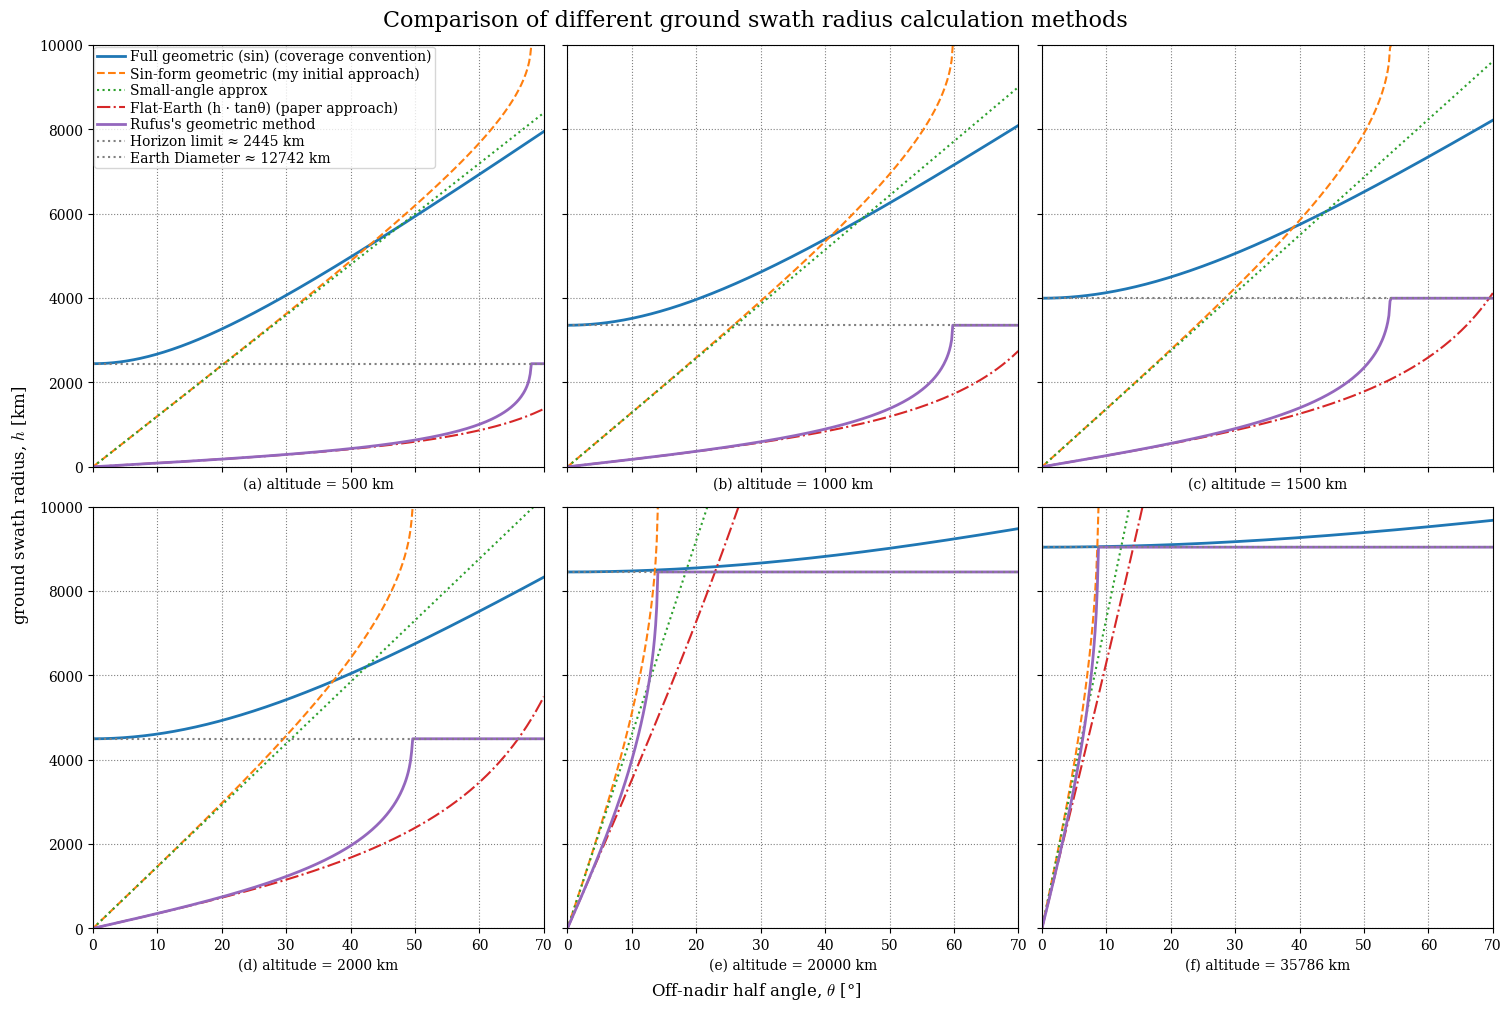

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Setup matplotlib
plt.style.use("default")
plt.rcParams.update({
    "mathtext.fontset": "cm",  # Computer Modern
    "font.family": "serif"
})

# Define Styles
plot_style_2x3 = {
    "linestyle": ":",
    "marker": "x",
    "markersize": 3,
}
subplot_style_2x3 = {
    "layout": "compressed",
    "sharex": True,
    "sharey": True,
    "figsize": (15, 10),
}
legend_style = {
    "borderpad": 0.2,
    "labelspacing": 0.2,
    "handletextpad": 0.4,
    "borderaxespad": 0.1,
}


def centered_grid_labels(fig, axes, xlabel, ylabel):
    fig.supxlabel(" ")
    fig.supylabel(" ")

    # Draw the figure once so layout managers compute positions
    fig.canvas.draw()

    # Get the bounding box of the entire grid of axes
    bboxes = [ax.get_position() for ax in axes.flatten()]
    left = min([b.x0 for b in bboxes])
    right = max([b.x1 for b in bboxes])
    bottom = min([b.y0 for b in bboxes])
    top = max([b.y1 for b in bboxes])

    # Compute the center positions
    xcenter = (left + right) / 2
    ycenter = (bottom + top) / 2

    # ---------------------------
    # Add grid-level labels
    # ---------------------------
    fig.text(xcenter, 0.02, xlabel, ha='center', va='bottom')
    fig.text(0.02, ycenter, ylabel, ha='left',
             va='center', rotation='vertical')

fig, axes = plt.subplots(2, 3, **subplot_style_2x3)
def idx(i): return i//3, i % 3
def sub_cap(i): return chr(i + ord('a'))


# Constants
R_E = 6371  # Earth radius in km
altitudes = [500, 1000, 1500, 2000, 20000, 35786]  # km
min_angle_deg = 0 # half angle
max_angle_deg = 70 # half angle

earth_diameter = R_E * 2

for i, h in enumerate(altitudes):

    theta_deg = np.linspace(min_angle_deg, max_angle_deg, 400)
    theta_rad = np.radians(theta_deg)

    # 1. Full geometric footprint (correct)
    r_cos = R_E * np.arccos((R_E / (R_E + h)) * np.cos(theta_rad))

    # 2. Sin-based geometric alternative (approximate)
    arg = ((R_E + h) / R_E) * np.sin(theta_rad)
    arg = np.clip(arg, -1, 1)
    r_sin = R_E * np.arcsin(arg)

    # 3. Linear small-angle approximation
    r_small = (R_E + h) * theta_rad

    # 4. Flat-Earth projection
    r_flat = h * np.tan(theta_rad)

    # 5. Rufus's method (geometric)
    theta_horizon = np.asin(R_E / (R_E + h))
    r_horizon = R_E * np.acos(R_E / (R_E + h))

    arg = (R_E + h)/R_E * np.sin(theta_rad)
    arg_clipped = np.clip(arg, -1, 1)

    r_rufus = np.where(
        theta_rad <= theta_horizon,
        R_E * (np.arcsin(arg_clipped) - theta_rad),
        r_horizon
    )

    # Horizon distance for reference
    r_horizon = R_E * np.arccos(R_E / (R_E + h))

    # Plot
    axis = axes[idx(i)]
    axis.plot(theta_deg, r_cos,label="Full geometric (sin) (coverage convention)", linewidth=2)
    axis.plot(theta_deg, r_sin, "--", label="Sin-form geometric (my initial approach)")
    axis.plot(theta_deg, r_small, ":", label="Small-angle approx")
    axis.plot(theta_deg, r_flat, "-.",label="Flat-Earth (h · tanθ) (paper approach)")
    axis.plot(theta_deg, r_rufus,label="Rufus's geometric method", linewidth=2)
    axis.axhline(r_horizon, color="gray", linestyle=":",label=f"Horizon limit ≈ {r_horizon:.0f} km")
    axis.axhline(earth_diameter, color="gray", linestyle=":",label=f"Earth Diameter ≈ {earth_diameter:.0f} km")

    axis.set_xlim(min_angle_deg, max_angle_deg)
    axis.set_ylim(0, 10000)

    axis.set_xlabel(f"({sub_cap(i)}) altitude = {h} km")
    axis.grid(True, linestyle=":", color="gray")

# only display the legend once
handles, labels = axes[0, 0].get_legend_handles_labels()
axes[idx(0)].legend(handles, labels, loc="upper left", **legend_style)

fig.suptitle("Comparison of different ground swath radius calculation methods", fontsize=16)
fig.supxlabel(r"Off-nadir half angle, $\theta$ [°]")
fig.supylabel("ground swath radius, $h$ [km]")

plt.show()